# Generate cell-specific GRNs for human pancreas with scCAFM SFM

This tutorial shows how to infer cell-specific gene regulatory networks (GRNs) from a human pancreas single-cell dataset. The workflow keeps a few medium-sized objects visible so it is easy to understand what is happening: the preprocessed AnnData, the dense forward GRN tensor, and a minimal exported edge table.

The final edge table is intentionally compact. It contains only the cell index and TF-to-target gene names, which makes it easier to inspect, save, and reuse in downstream analysis.


## 1. Environment

Install scCAFM with `pip install -e .`, then run this notebook from the repository root or from `docs/`. The first cell only resolves repository-relative data and config paths.


In [1]:
from pathlib import Path

start = Path.cwd().resolve()
repo_root = start if (start / "configs").exists() else start.parent
if not (repo_root / "configs").exists():
    raise RuntimeError("Run this notebook from the scCAFM repository root or docs/.")

import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Arial"

from sccafm import grn

print(f"Repository root: {repo_root}")


Repository root: /data1021/xukaichen/scCAFM


## 2. Configure inputs

The pancreas dataset path is the runnable default for this tutorial. `n_top_genes` controls how many HVGs are kept after preprocessing, while `max_length` controls the tokenizer sequence capacity and should be larger than the selected gene count.

`top_k_per_cell` controls how many high-ranking TF-to-target edges are exported for each cell. The saved CSV stays minimal even though scores are used internally for ranking.


In [2]:
input_h5ad = Path("/data1021/xukaichen/data/GRN/datasets/pancreas.h5ad")
output_csv = repo_root / "results" / "pancreas_cell_specific_sfm_grn_edges.csv"

model_source = repo_root / "assets"
checkpoint_path = None

batch_size = 64
max_length = 1024
n_top_genes = 1000
top_k_per_cell = 1000
score_threshold = None

top_n_sources = 20
top_n_targets = 20
network_tf = "REST"
network_cell_type_key = "clusters"
network_n_cell_types = 4
network_cells_per_type = 1
network_top_targets_per_cell = 20

gene_key = None
species_key = "species"
disease_key = "disease"

print(f"Input: {input_h5ad}")
print(f"Output: {output_csv}")


Input: /data1021/xukaichen/data/GRN/datasets/pancreas.h5ad
Output: /data1021/xukaichen/scCAFM/results/pancreas_cell_specific_sfm_grn_edges.csv


## 3. Preprocess AnnData

This tutorial uses normal HVG preprocessing: one fixed active gene universe is selected for all cells. TF genes are not forced to remain before HVG selection, so the active genes are determined by the same standard HVG rule used for expression preprocessing.

The returned `run` object keeps the processed AnnData, tokenizer metadata, dataloader, and model together. For reading the tutorial, the most important object here is `processed_adata`, because its observations define the cell order used later in `forward_results` and `edges_df`.


In [3]:
run = grn.prepare(
    input_h5ad=input_h5ad,
    mode=grn.PreprocessMode.NORMAL_HVG,
    model_source=model_source,
    checkpoint_path=checkpoint_path,
    config_path=repo_root / "configs" / "eval_grn.yaml",
    batch_size=batch_size,
    max_length=max_length,
    n_top_genes=n_top_genes,
    gene_key=gene_key,
    species_key=species_key,
    disease_key=disease_key,
)

processed_adata = run.adata
print(f"Raw shape: {run.raw_adata.shape}")
print(f"Processed shape: {processed_adata.shape}")
processed_adata


Raw shape: (3696, 27998)
Processed shape: (3696, 1000)


AnnData object with n_obs × n_vars = 3696 × 1000
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'species', 'disease', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes'
    var: 'highly_variable_genes', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'log1p', 'hvg'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

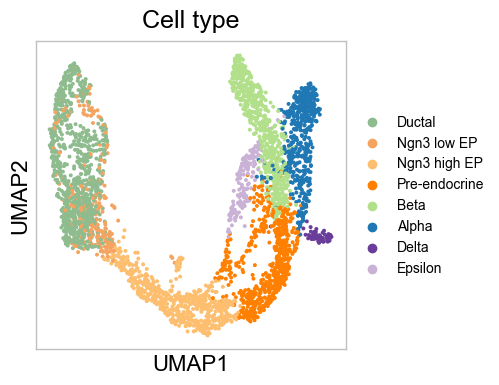

In [4]:
fig, ax = plt.subplots(figsize=(4, 4))

ax = sc.pl.umap(
    processed_adata,
    color="clusters",
    ax=ax,
    show=False
)

ax.set_xlabel("UMAP1", fontsize=16)
ax.set_ylabel("UMAP2", fontsize=16)
ax.set_title("Cell type", fontsize=18, pad=10)

for spine in ax.spines.values():
    spine.set_color("#C0C0C0")
    spine.set_linewidth(1)

plt.show(fig)


## 4. Collect forward results

`forward_results` is a dense NumPy array with shape `(cell, gene, gene)` after padding gene slots are removed. For example, if the processed dataset has 3,696 cells and 1,000 active genes, the expected shape is `(3696, 1000, 1000)`.

The second and third axes use the same active gene order. Each cell therefore has one predicted GRN matrix over the active gene universe.


In [5]:
forward_results = grn.predict(run)

print(f"forward_results shape: {forward_results.shape}")
print(f"forward_results dtype: {forward_results.dtype}")


forward_results shape: (3696, 1000, 1000)
forward_results dtype: float32


## 5. Build edge table

The dense tensor is useful as a model output, but it is too large for a readable tutorial table. Here we convert it into a compact edge table by keeping the top TF-to-active-gene predictions for each cell.

The exported table records only `cell_index`, `source_gene`, and `target_gene`. Scores and token IDs are used internally for filtering and ranking, but are not saved.


In [6]:
edges_df = grn.edges(
    run,
    forward_results,
    output_csv=output_csv,
    top_k_per_cell=top_k_per_cell,
    score_threshold=score_threshold,
)

print(f"Saved {len(edges_df):,} edges to {output_csv}")
print(f"Cells with exported edges: {edges_df['cell_index'].nunique():,}")
edges_df.head()


Saved 3,696,000 edges to /data1021/xukaichen/scCAFM/results/pancreas_cell_specific_sfm_grn_edges.csv
Cells with exported edges: 3,696


,cell_index,source_gene,target_gene
0,0,REST,TBC1D9
1,0,REST,OCRL
2,0,REST,KLHDC8A
3,0,REST,SUOX
4,0,REST,ACAA2


## 6. Visualize GRN edge properties and cell-specific networks

These figures summarize simple properties of the exported cell-specific GRNs without embedding the full dense GRN tensor.

The bar plots show which source TFs and target genes appear most often across exported edges. The network panels then focus on one TF and show its top exported target genes in representative cells from several cell types. This makes the cell-specific nature of the inferred GRNs easier to inspect than an aggregate TF-target heatmap.


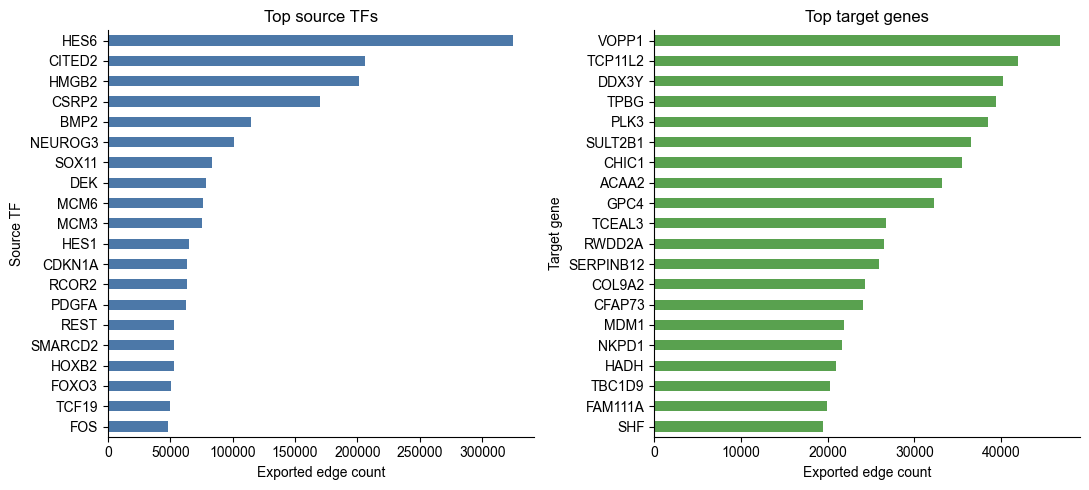

In [7]:
if edges_df.empty:
    print("No edges were exported. Increase `top_k_per_cell` or relax `score_threshold`.")
else:
    source_counts = edges_df["source_gene"].value_counts().head(top_n_sources).sort_values()
    target_counts = edges_df["target_gene"].value_counts().head(top_n_targets).sort_values()

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))

    source_counts.plot.barh(ax=axes[0], color="#4C78A8")
    axes[0].set_xlabel("Exported edge count")
    axes[0].set_ylabel("Source TF")
    axes[0].set_title("Top source TFs")

    target_counts.plot.barh(ax=axes[1], color="#59A14F")
    axes[1].set_xlabel("Exported edge count")
    axes[1].set_ylabel("Target gene")
    axes[1].set_title("Top target genes")

    for ax in axes:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.tight_layout()
    plt.show()


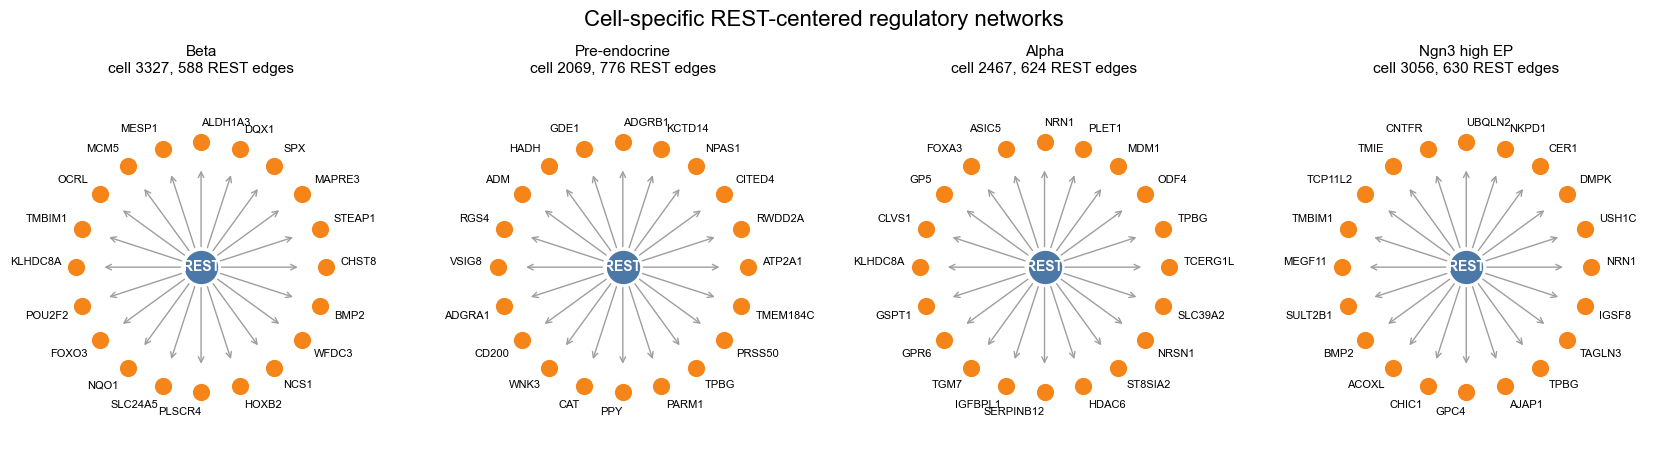

In [8]:
if edges_df.empty:
    print("No edges were exported. Increase `top_k_per_cell` or relax `score_threshold`.")
elif network_cell_type_key not in processed_adata.obs:
    print(f"`{network_cell_type_key}` is not available in `processed_adata.obs`.")
else:
    tf_edges_df = edges_df[edges_df["source_gene"] == network_tf].copy()
    if tf_edges_df.empty:
        print(f"No exported edges found for source TF `{network_tf}`.")
    else:
        cell_types = processed_adata.obs[network_cell_type_key].astype(str).reset_index(drop=True)
        tf_edges_df["cell_type"] = tf_edges_df["cell_index"].map(cell_types)
        eligible_cell_types = (
            cell_types.iloc[tf_edges_df["cell_index"].drop_duplicates()]
            .value_counts()
            .head(network_n_cell_types)
            .index
        )

        representative_rows = []
        for cell_type in eligible_cell_types:
            cell_type_edges = tf_edges_df[tf_edges_df["cell_type"] == cell_type]
            top_cells = (
                cell_type_edges.groupby("cell_index")
                .size()
                .sort_values(ascending=False, kind="mergesort")
                .head(network_cells_per_type)
            )
            for cell_index, edge_count in top_cells.items():
                representative_rows.append(
                    {
                        "cell_type": cell_type,
                        "cell_index": int(cell_index),
                        "edge_count": int(edge_count),
                    }
                )

        if not representative_rows:
            print(f"No representative cells found for source TF `{network_tf}`.")
        else:
            n_panels = len(representative_rows)
            fig, axes = plt.subplots(1, n_panels, figsize=(4.2 * n_panels, 4.4), squeeze=False)
            axes = axes.ravel()

            for ax, row in zip(axes, representative_rows):
                cell_index = row["cell_index"]
                cell_edges = tf_edges_df[tf_edges_df["cell_index"] == cell_index]
                targets = cell_edges["target_gene"].drop_duplicates().head(network_top_targets_per_cell).tolist()

                ax.scatter([0], [0], s=650, color="#4C78A8", edgecolor="white", linewidth=1.5, zorder=3)
                ax.text(0, 0, network_tf, ha="center", va="center", color="white", fontsize=10, fontweight="bold")

                if targets:
                    angles = np.linspace(0, 2 * np.pi, len(targets), endpoint=False)
                    radius = 1.0
                    xs = radius * np.cos(angles)
                    ys = radius * np.sin(angles)

                    for target, x, y in zip(targets, xs, ys):
                        ax.annotate(
                            "",
                            xy=(x * 0.82, y * 0.82),
                            xytext=(0.12 * x, 0.12 * y),
                            arrowprops={"arrowstyle": "->", "color": "#9E9E9E", "lw": 1.0, "shrinkA": 4, "shrinkB": 4},
                        )
                    ax.scatter(xs, ys, s=180, color="#F58518", edgecolor="white", linewidth=1.0, zorder=3)

                    for target, x, y in zip(targets, xs, ys):
                        ha = "left" if x >= 0 else "right"
                        va = "bottom" if y >= 0 else "top"
                        ax.text(x * 1.12, y * 1.12, target, ha=ha, va=va, fontsize=8)
                else:
                    ax.text(0, -0.35, "No targets", ha="center", va="center", fontsize=9, color="#666666")

                ax.set_title(
                    f"{row['cell_type']}\ncell {cell_index}, {row['edge_count']} {network_tf} edges",
                    fontsize=11,
                    pad=10,
                )
                ax.set_xlim(-1.45, 1.45)
                ax.set_ylim(-1.45, 1.45)
                ax.set_aspect("equal")
                ax.axis("off")

            fig.suptitle(f"Cell-specific {network_tf}-centered regulatory networks", fontsize=16, y=1.03)
            fig.tight_layout()
            plt.show()


The orange nodes represent the top REST-linked target genes inferred from cell-specific REST-centered regulatory networks. These genes should be interpreted as candidate REST-associated regulatory targets in each cellular state, rather than validated direct REST targets. The marked differences among beta, pre-endocrine, alpha and Ngn3-high endocrine progenitor cells suggest that REST is embedded in distinct regulatory neighborhoods across endocrine differentiation. In particular, REST-associated targets in Ngn3-high endocrine progenitors and pre-endocrine cells are enriched for developmental, signaling and neuroendocrine-like genes, whereas the beta-cell network is more associated with stress, survival and noncanonical plasticity-related programs.

## 7. Notes

- `cell_index` is the row index after preprocessing, so it matches `processed_adata.obs`.
- Sources are restricted to TFs; targets are all active processed genes.
- `forward_results` contains all processed cells, so it can be reused for later predicted-result inspection.
- The bar plots summarize exported edge frequencies, while the network panels show examples from individual cells.
- Edge scores are not saved in `edges_df`, so the network panels use the score-sorted export order from `grn.edges(...)`.
